In [1]:
# Necessary libraries and useful parameters
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.colorbar as cb

import scipy.sparse as sp
import warnings
warnings.simplefilter("ignore", RuntimeWarning)

newparams = {'font.family': 'cmr10', 'mathtext.fontset': 'cm',
             'axes.grid': False, 'axes.labelsize': 22,
             'xtick.labelsize': 18, 'ytick.labelsize': 18,
             'legend.fontsize': 18, 'axes.titlesize': 20,
             'figure.figsize': (9,6), 'lines.linewidth': 2.5,
             'axes.formatter.use_mathtext': True}
plt.rcParams.update(newparams)
%matplotlib inline

In [2]:
# Color maps
concentration_colors = ["#00274D", "#1B4F72", "#CFA6A6", "#CD5C5C", "#8B3A3A", "#641010"]
concentration_cmap = mcolors.LinearSegmentedColormap.from_list("custom_blue_map", concentration_colors)

deposition_colors = ["#F6CCCC", "#CD5C5C", "#641010"]
deposition_cmap = mcolors.LinearSegmentedColormap.from_list("custom_reds", deposition_colors)

In [3]:
# Model constants
R = 0.1   # tube radius [m]
L = 1   # tube length [m]
T = 100 # Characteristic time

domain = ((0, 1), (0, 1), (0, 1))
M, K = 200, 100
h, ht = 1/M, 1/K

z = np.linspace(domain[0][0], domain[0][1], M+1)
r = np.linspace(domain[1][0], domain[1][1], M+1)
t = np.linspace(domain[2][0], domain[2][1], K+1)

grid = (z, r)
ZZ, RR = np.meshgrid(z, r) 

In [4]:
# Scaled block matrix coefficients
def matrix_coeffs(params):
    E, U, D, kA = params

    δ = ht/h**2 * D
    γ = δ * (R/L)**2
    ξ = ht/h * D*(E-1)/r
    𝜗 = ht/h * U*(1-r**2)
    ω = ξ + 𝜗 + 2*(γ + δ) + 1

    return δ, γ, ξ, 𝜗, ω

In [5]:
def coeff_matrix(M:int, coeffs) -> sp.csr_matrix:
    '''
    Create the block tridiagonal matrix A to solve AC^k+1 + g = -C^k.
    Input:
        M: number of grid points
    '''
    Z = M*(M-1)
    δ, γ, ξ, 𝜗, ω = coeffs

    ll = np.repeat(δ + ξ[1:-1], M)      # Lowest diag
    l = np.repeat(γ + 𝜗[1:-1], M) # Next lowest diag
    d = np.repeat(ω[1:-1], M)            # Main diag 
    u = np.full(Z, γ)                    # Next highest diag
    uu = np.full(Z, δ)                   # Highest diag
    
    l[M-1::M], u[M-1::M] = 0, 0 # Every M'th element is zero in l and d
    
    A = sp.diags([ll, l, -d, u, uu], [-M, -1, 0, 1, M], (Z, Z), format='csr')

    return A

In [6]:
def boundary_vector(grid:tuple, k:int, qk:np.ndarray, Ck:np.ndarray, BC:tuple, M:int, coeffs, params) -> np.ndarray:
  ''' 
  Create the boundary vector g to solve AC^k+1 + g = -C^k.
  Input:
    grid: (r, z) grids in r- and z directions
       k: the previous iteration step
      Ck: the previous concentration matrix
      BC: (g1, g2, g3) boundary condition functions
       M: number of grid points
  '''
  z, r = grid
  g1, g2, g3 = BC
  δ, γ, ξ, 𝜗, ω = coeffs
  
  # Construct a matrix containing boundary contributions.
  G = np.zeros((M-1, M))
  G[::-1, 0] += (γ+𝜗[1:-1]) * g1(r[1:-1], t[k+1]) # Left contribution
  G[-1, :] += (δ+ξ[1]) * g2(z[1:], t[k+1])              # Bottom contribution
  G[0, :] += δ * g3(qk[1:], Ck[-2, 1:], params)                   # Top contribution

  return G[::-1].ravel() # return G as a vector

In [7]:
def concentration_scheme(grid:tuple, A:np.ndarray, g:np.ndarray, k:int, qk:np.ndarray, Ck:np.ndarray, BC:tuple, M:int, params) -> np.ndarray:
    '''
    Calculate the next concentration matrix C^k+1.
    Input:
        grid: (r, z) grids in r- and z directions
           A: the coefficient matrix
           k: the previous iteration step
          Ck: the previous concentration matrix
           g: the boundary vector
          BC: (g1, g2, g3) boundary condition functions
           M: number of grid points
    '''
    z, r = grid
    g1, g2, g3 = BC
   
    C = np.zeros((M+1, M+1))
    C[::-1, 0] = g1(r, t[k+1]) # Left boundary
    C[-1, :] = g2(z, t[k+1])   # Bottom boundary  
    C[0, 1:] = g3(qk[1:], Ck[-2, 1:], params) # Top boundary

    C_interior = sp.linalg.spsolve(A, -(g + Ck[1:-1, 1:][::-1].ravel()))
    C[1:-1, 1:] = np.reshape(C_interior, (M-1, M))
   
    return C

In [8]:
def RK4(f, q, C, params):
    ''' 
    Solve a set of ODE's using the RK4-method.
    Input:
        f: the right hand side of the differential equations. Here: The Langmuir model
        q: initial values
        C: concentration matrix
        params: parameters needed by f. Here: [E, U, D, kA]
    '''
    k1 = f(q, C, params)
    k2 = f(q+ht*k1/2, C, params)
    k3 = f(q+ht*k2/2, C, params)
    k4 = f(q+ht*k3, C, params)
    
    return q + h/6*(k1 + 2*(k2 + k3) + k4)

In [9]:
# Initial condition
def f(z, r):                   
    return np.zeros_like(ZZ)   
                                                         
# Boundary conditions
def i(r, t): # inlet
    return 1-r**2  

def e(z, t): # electric
    return 0

def langmuir(q, C, params): # RHS of langmuir model to be solved with RK4
    E, U, D, kA = params
    return kA*C*(1-q)

def d(qk, C, params): # deposition (discretized)
    E, U, D, kA = params
    return C / (1 - h*((E*R)/r[-1] + kA/D *(1-qk)))

In [10]:
# Simulator functions

def contour_plot(Z, R, C, dCz=None, dCr=None, skip=12):
    # Plot base concentration contour
    contour = plt.contourf(Z, R, C, levels=200, cmap=concentration_cmap)
    cbar = plt.colorbar(contour, label=r'$c/c_{\mathrm{max}}$')

    if dCz is not None and dCr is not None:
        Z_skip   = Z[::skip, ::skip]   # Subsample for clarity
        R_skip   = R[::skip, ::skip]
        dCz_skip = dCz[::skip, ::skip]
        dCr_skip = dCr[::skip, ::skip]

        mag = np.sqrt(dCz_skip**2 + dCr_skip**2)

        # Enhance contrast in lengths using exponent
        exponent = 0.04
        mag_scaled = mag**exponent
        mag_scaled /= np.max(mag_scaled)  # Normalize to [0, 1]

        dCz_scaled = dCz_skip * mag_scaled / mag  # Scale vector components by adjusted magnitude
        dCr_scaled = dCr_skip * mag_scaled / mag

        arrow_length = 0.1      # Rescale to desired max arrow length
        dCz_final = dCz_scaled * arrow_length
        dCr_final = dCr_scaled * arrow_length

        plt.quiver(Z_skip, R_skip, dCz_final, dCr_final, width=0.003, color='slategrey', scale=1.5, scale_units='xy')

    plt.xlabel('$z/L$')
    plt.ylabel('$r/R$')
    plt.gca().set_aspect(aspect=0.6, adjustable='box')
    plt.show()

In [11]:
def simulate_concentration(E, U, D, kA, label=None, show_contour=False, snapshot_times=(0, 0.04, 0.14, 0.49)):
    params = [E, U, D, kA]
    coeffs = matrix_coeffs(params)
    A = coeff_matrix(M, coeffs)
    BC = (i, e, d)

    Ck = f(ZZ, RR)         # Initial concentration matrix
    qk = np.zeros(M+1)     # Initial wall surface coverage
    Cwall = np.zeros((K, M+1))

    # Convert fractions of time domain into indices
    snapshot_indices = set(np.round(np.array(snapshot_times) * (K - 1)).astype(int))

    for k, time in enumerate(t[:-1]):
        g = boundary_vector(grid, k, qk, Ck, BC, M, coeffs, params)
        C = concentration_scheme(grid, A, g, k, qk, Ck, BC, M, params)
        dCr, dCz = np.gradient(C, h, h)

        Cwall[k] = C[0]
        q = RK4(langmuir, qk, C[-1, :], params)

        if show_contour and k in snapshot_indices:
            plt.figure()
            plt.title(f'$t/T = {time+ht:.2f}$')
            contour_plot(ZZ, RR, C, -dCz, -dCr) # Note: negative gradient is flow direction

        Ck = C
        qk = q

    return Cwall

In [12]:
def simulate_deposition(Cwall, profiles=20):
    plt.figure()

    # Select "profiles" evenly spaced indices from the time steps
    profile_indices = np.round(np.linspace(0, K - 1, profiles)).astype(int)

    for j, k in enumerate(profile_indices):
        color = deposition_cmap(j / max(1, profiles - 1))  # Normalize color mapping
        plt.plot(z, Cwall[k], color=color)

    plt.xlabel('$z/L$')
    plt.ylabel(r'$c/c_{\mathrm{max}}$')
    plt.grid(True)

    sm = plt.cm.ScalarMappable(cmap=deposition_cmap, norm=plt.Normalize(vmin=t[0], vmax=t[-1]))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label('$t/T$')
    plt.show()

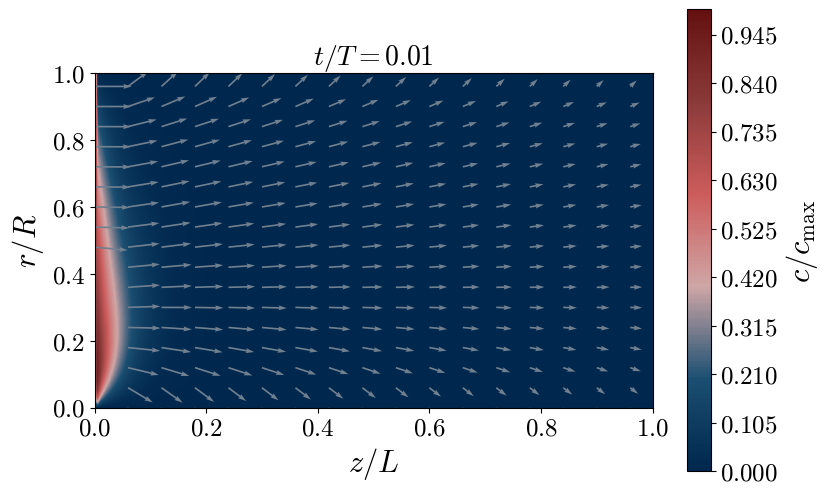

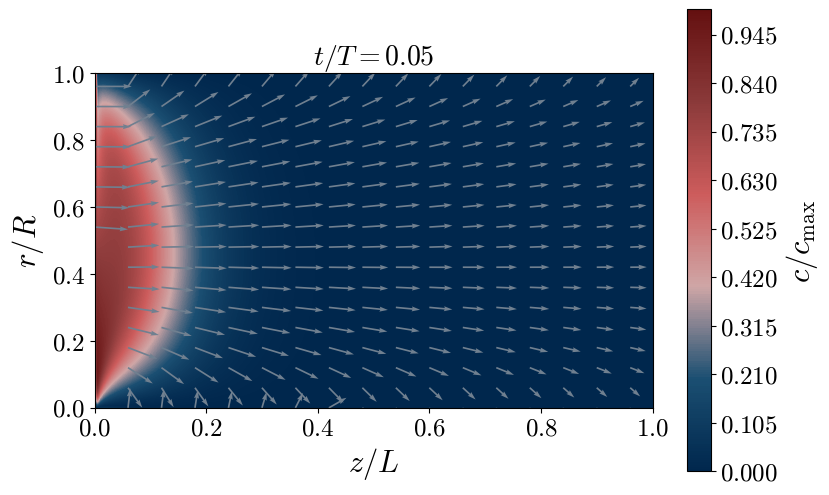

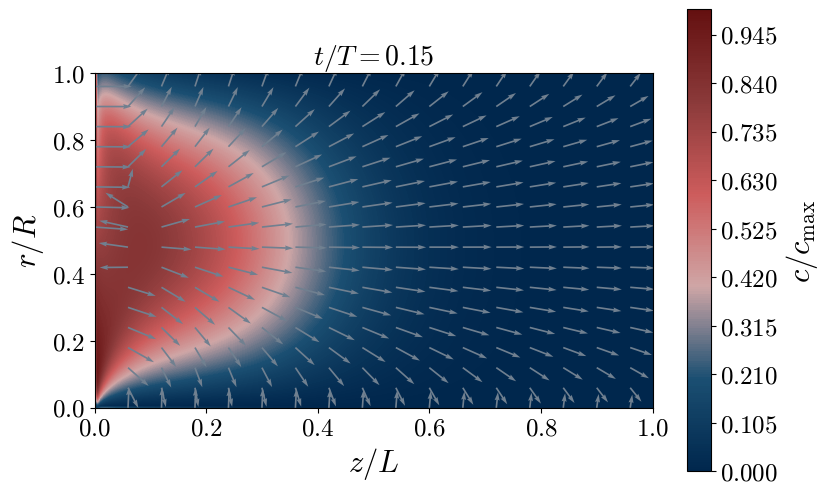

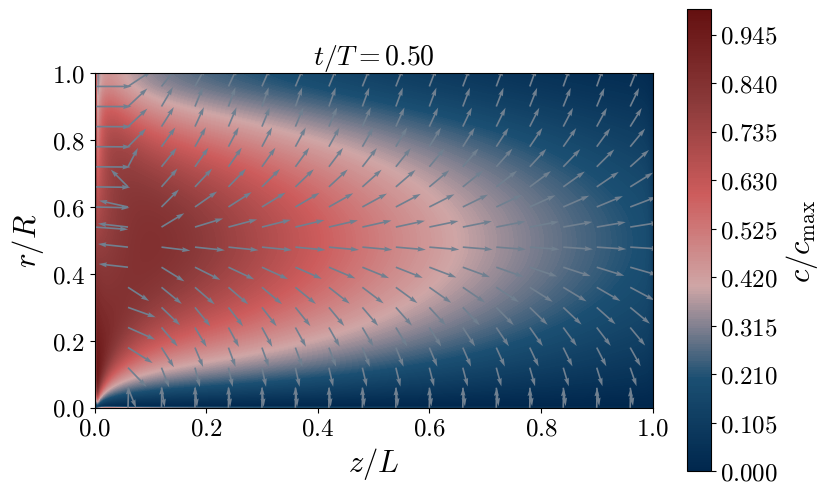

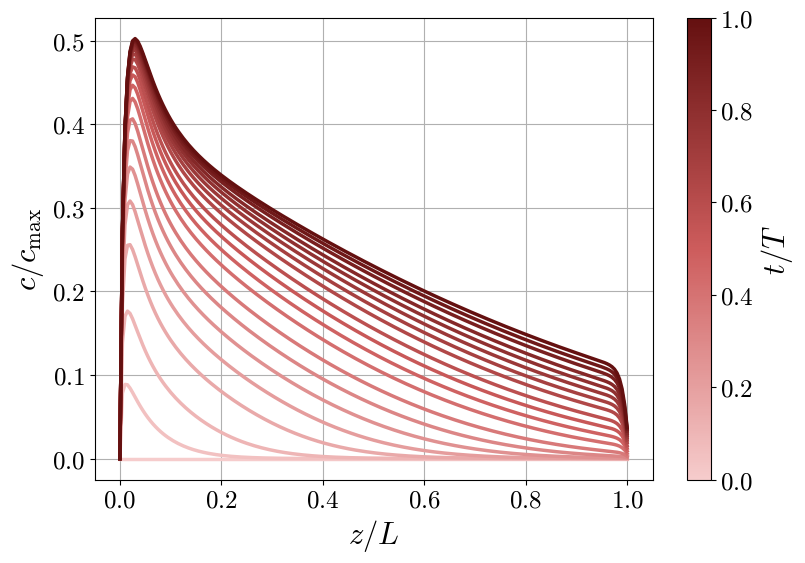

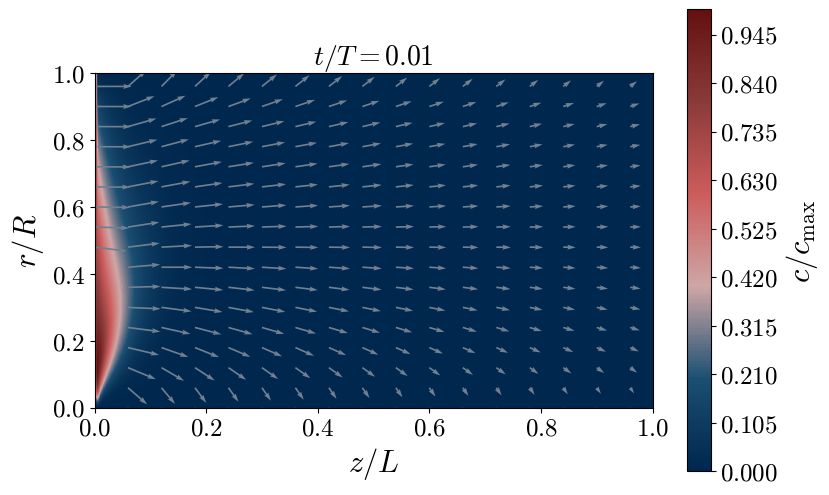

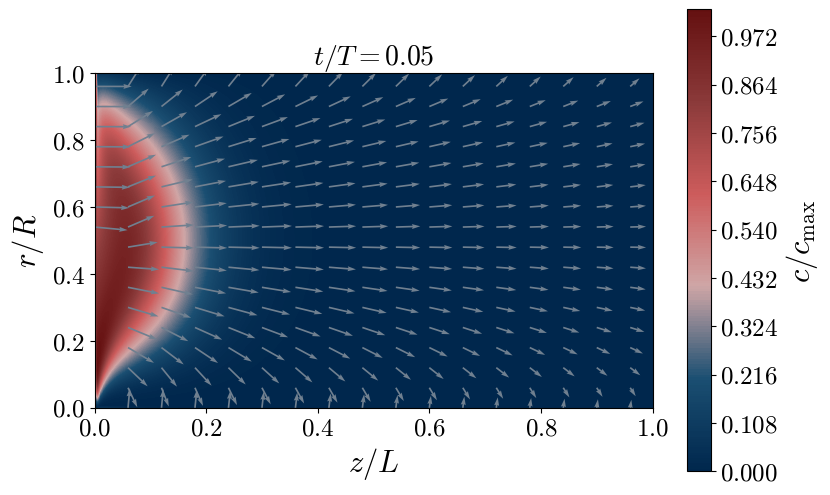

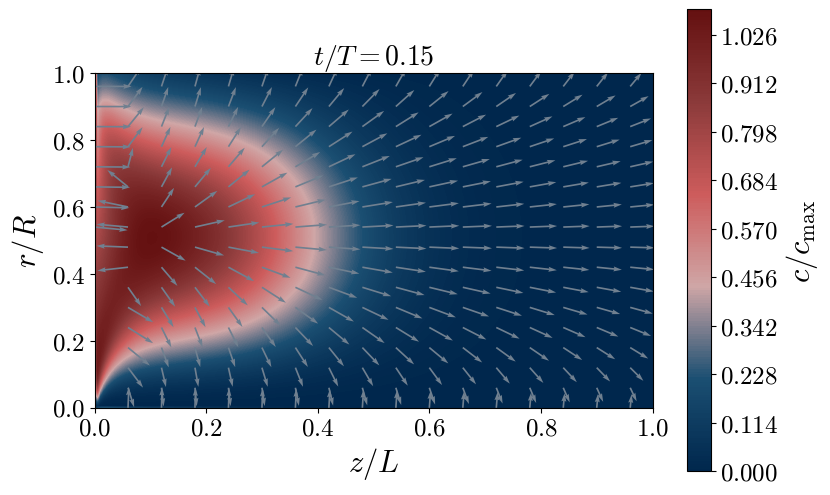

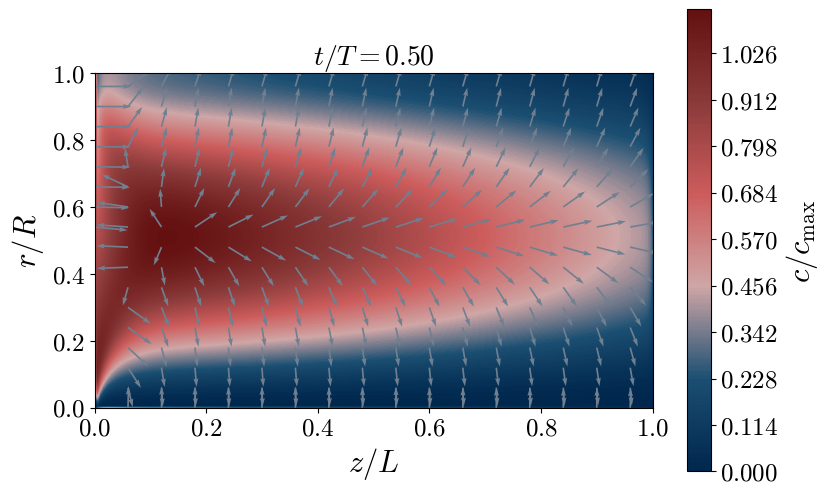

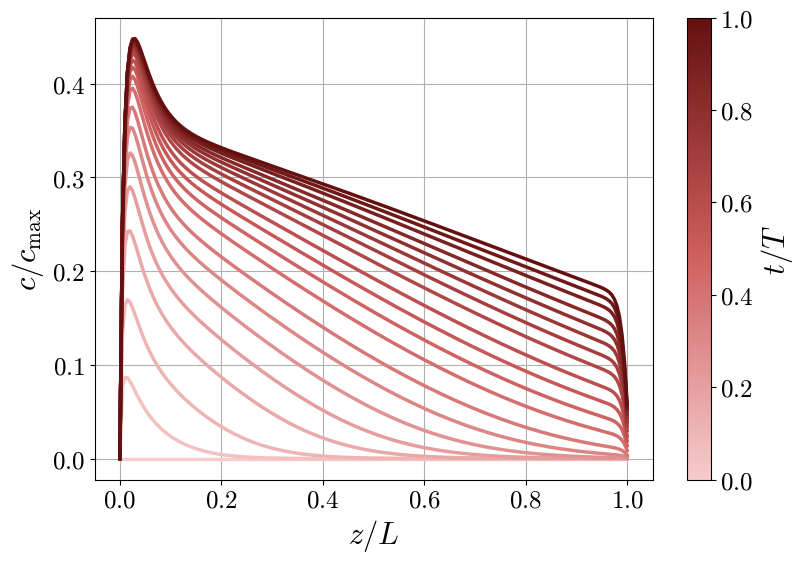

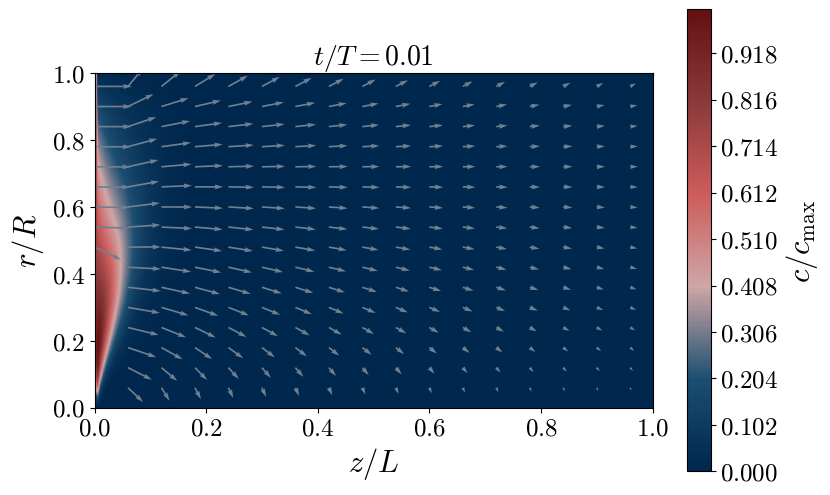

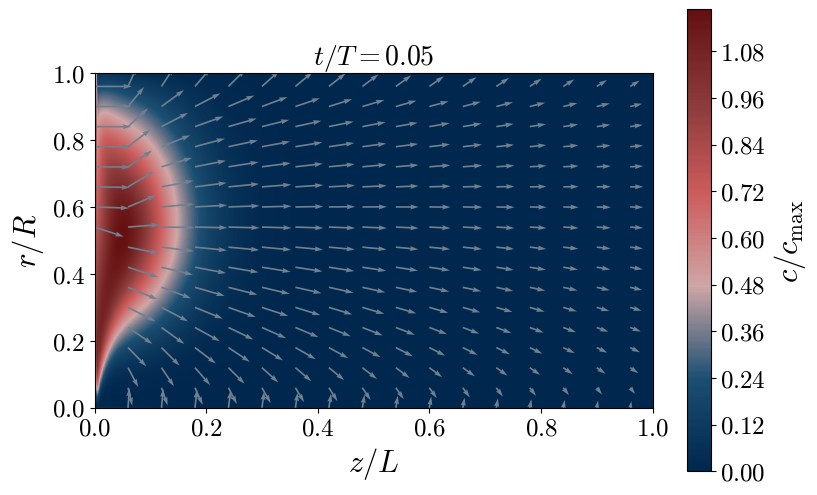

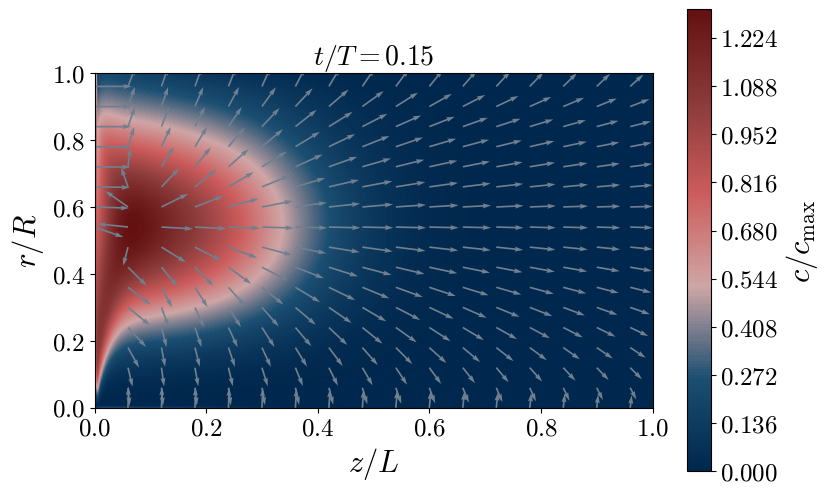

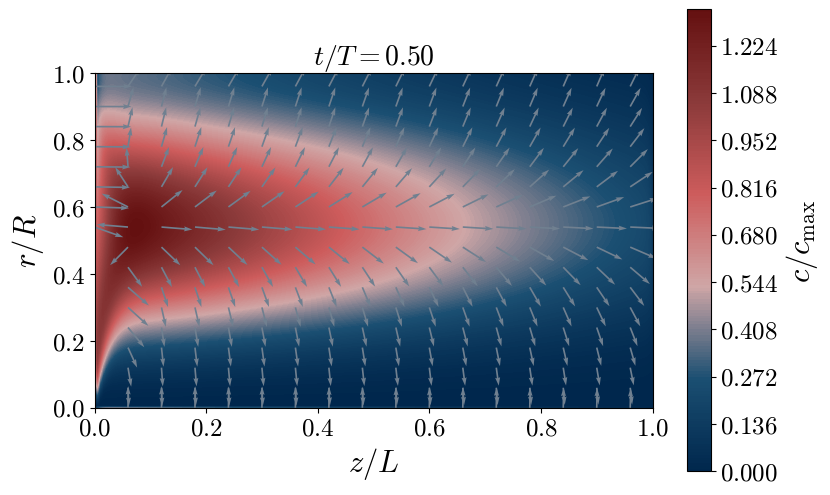

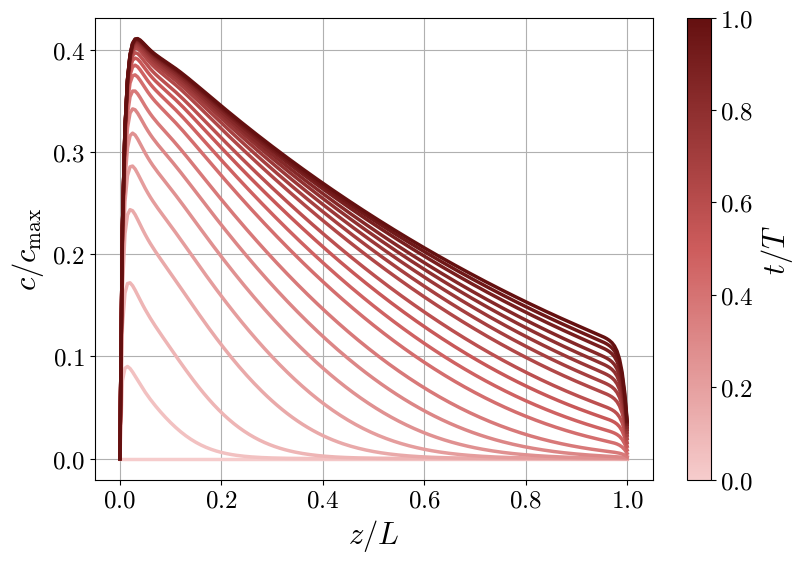

In [13]:
# Example 1: Varying E, contour plots, deposition profile
U, D, kA = 4, 1, 1
E_list = [2, 4, 8]
for E in E_list:
    Cwall = simulate_concentration(E, U, D, kA, show_contour=True)
    simulate_deposition(Cwall)

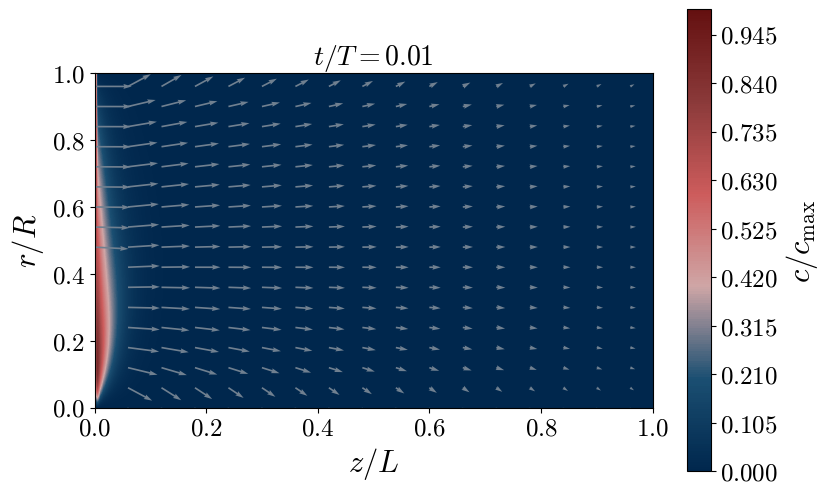

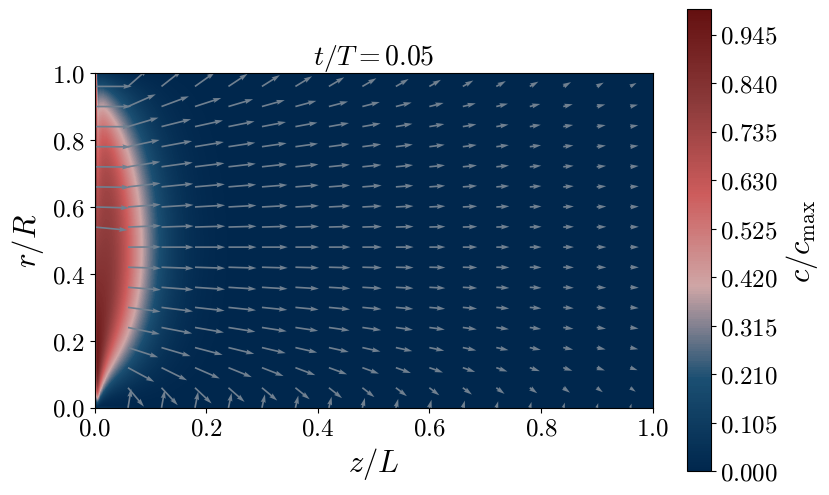

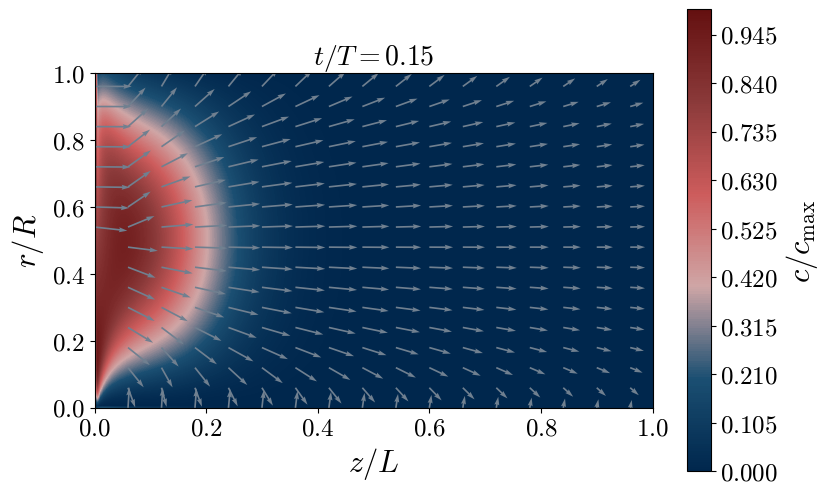

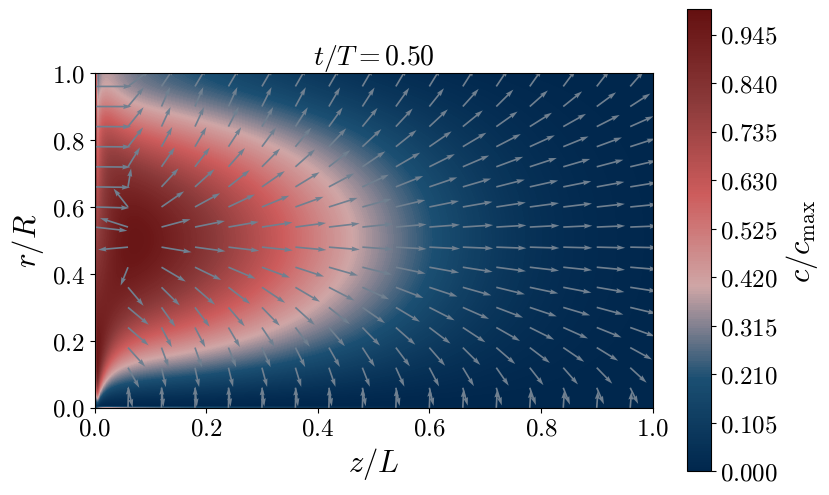

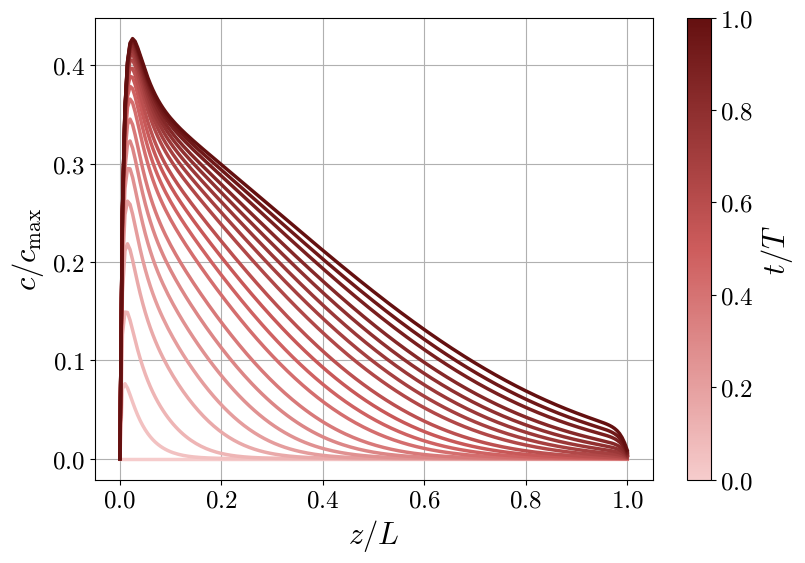

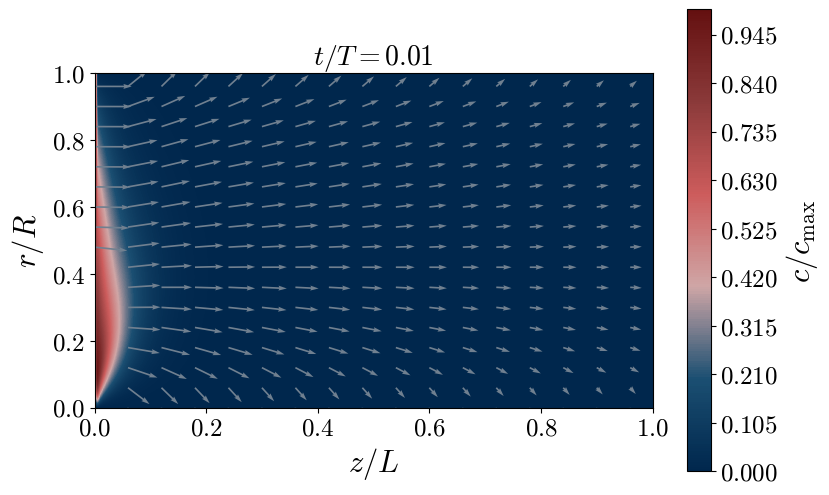

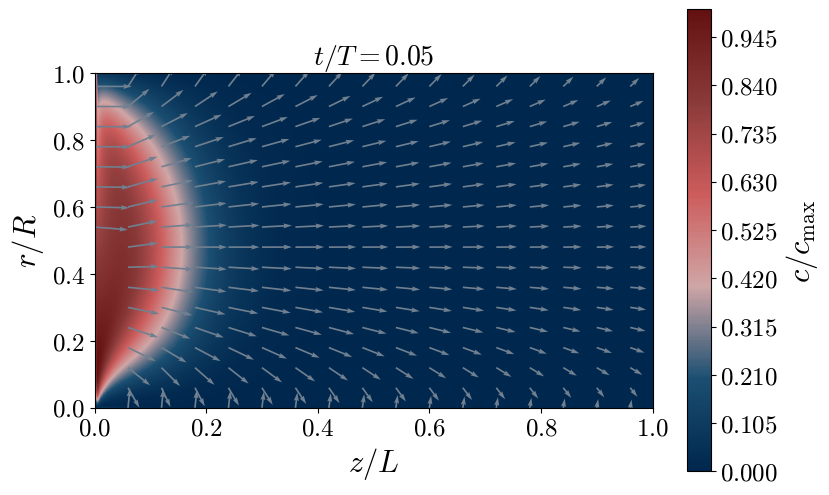

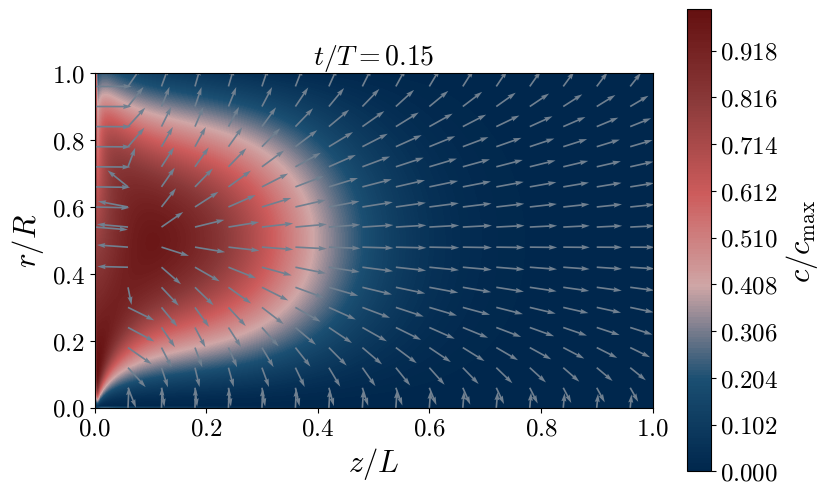

In [ ]:
# Example 2: Varying U, contour plots, deposition profile
E, D, kA = 3, 1, 1
U_list = [2, 4, 8]
for U in U_list:
    Cwall = simulate_concentration(E, U, D, kA, show_contour=True)
    simulate_deposition(Cwall)

In [ ]:
# Example 3: Varying D, contourplots, deposition profile
E, U, kA = 3, 4, 1
D_list = [0.5, 1, 3]
for D in D_list:
    Cwall = simulate_concentration(E, U, D, kA, show_contour=True)
    simulate_deposition(Cwall)

In [ ]:
# Example 4: Varying kA, contour plots, deposition profile
E, U, D = 3, 4, 1
kA_list = [0.5, 2, 5]
for kA in kA_list:
    Cwall = simulate_concentration(E, U, D, kA, show_contour=True)
    simulate_deposition(Cwall)